# Day 19

#### Start with what we missed yesterday: Independent Component Analysis


When the components are statistically independent (fitting name right), we can use ICA to separate mixed components.

The classical example is the so-called "cocktail party" problem. This is illustrated in the following figure from Hastie, Tibshirani, & Friedman. Think of the "source signals" as two voices at a party. You are trying to concentrate on just one voice. What you hear is something like the "measured signals" pattern. You could run the data through PCA and that would do an excellent job of reconstructing the signal with reduced dimensionality, but it wouldn't actually isolate the different physical components (bottom-left panel). ICA on the other hand can (bottom-right panel).

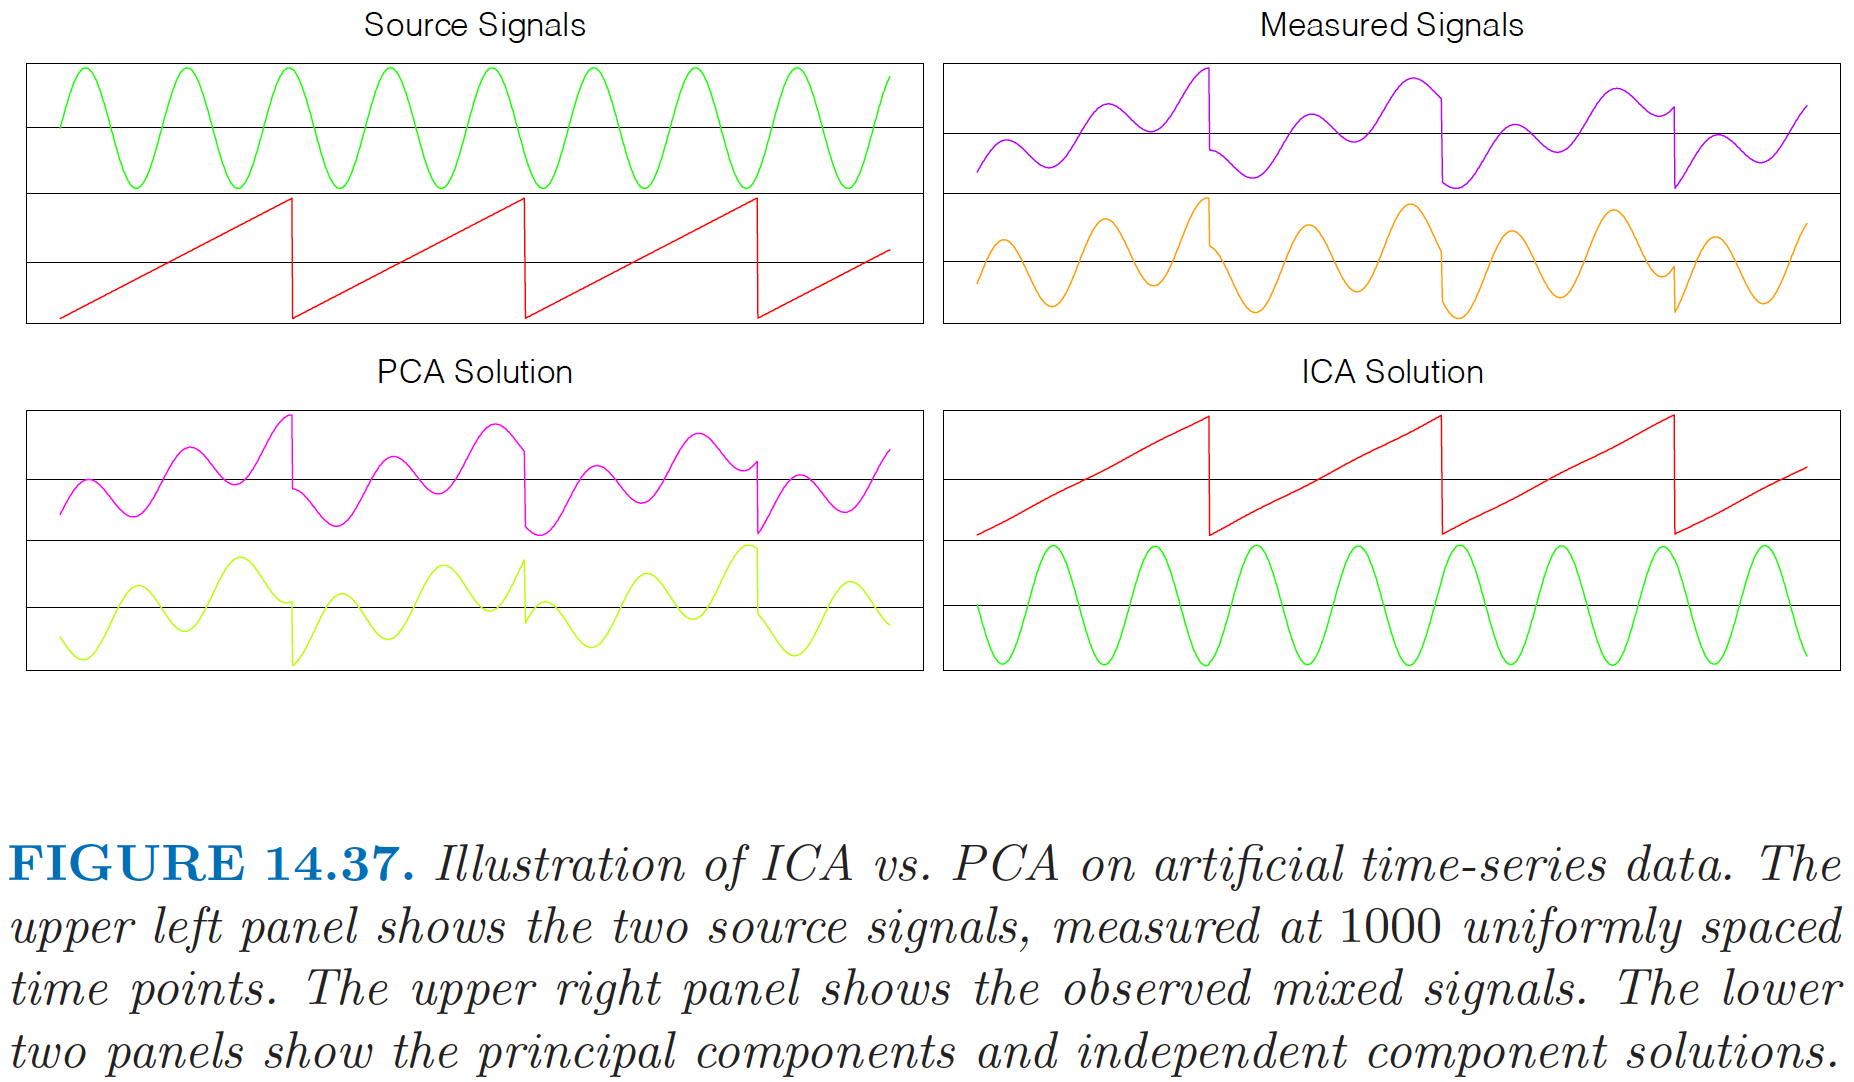

So let's say we have two sources $S_1(t)$, $S_2(t)$ but the microphones may record:

$$x_1(t) = 0.8S_1(t) + 0.3S_2(t) \qquad \qquad x_2(t) = 0.4S_1(t) + 0.9S_2(t)$$

We never directly observe $s_1$ or $s_2$ but we see their mixtures.

In matrix form this looks like $\mathbf{x} = \mathbf{AS}$

Ideally, then we can find $\mathbf{S = A^{-1}x}$

But we do not not the inverse of A, so ICA tries an unmixing matrix $\mathbf{W \approx A^{-1}}$ such that $\mathbf{\hat{S} = WX}$

**ICA here makes the components independent, whereas PCA from before makes it uncorrelated**

We know that when we mix things, things start to look more Gaussian due to CLT. So we want to apply the opposite logic for unmixing and go towards high non-gaussianity. This helps find independent sources.

> ICA is good for complex systems with relatively independent systems. For example, a galaxy is roughly a linear combination of cool and hot stars. We want eigenvectors that are aligned with these physical traits/regions.


In [28]:
# Execute this cell
import numpy as np
from sklearn.decomposition import FastICA

X = np.random.normal(size=(100,2)) # 100 objects in 2D
R = np.random.random((2,5)) # mixing matrix
X = np.dot(X,R) # Simulation of a 5D data space

ica = FastICA(n_components=2) # Now reproject to 2-D
ica.fit(X)

proj = ica.transform(X) # 100x2 projection of the data
comp = ica.components_ # 2x5 matrix of independent components
## sources = ica.sources_ # 100x2 matrix of sources

## Lecture 16 Dimensional Reduction II 



In [29]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

What can we do to the handwritten digits that we had before? (I need to come back to do this exercise properly)

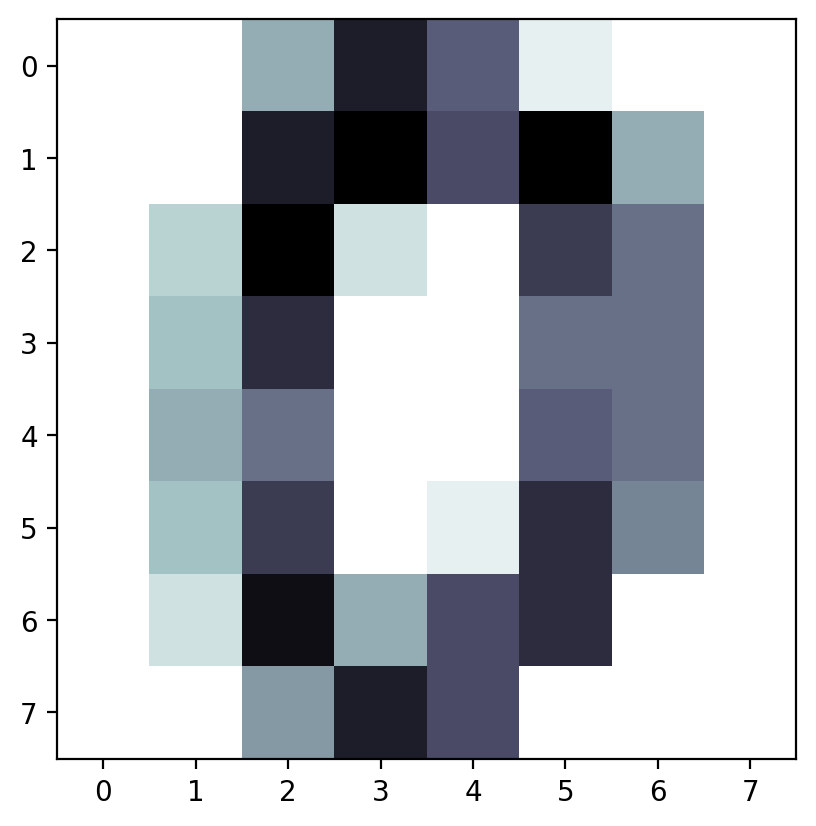

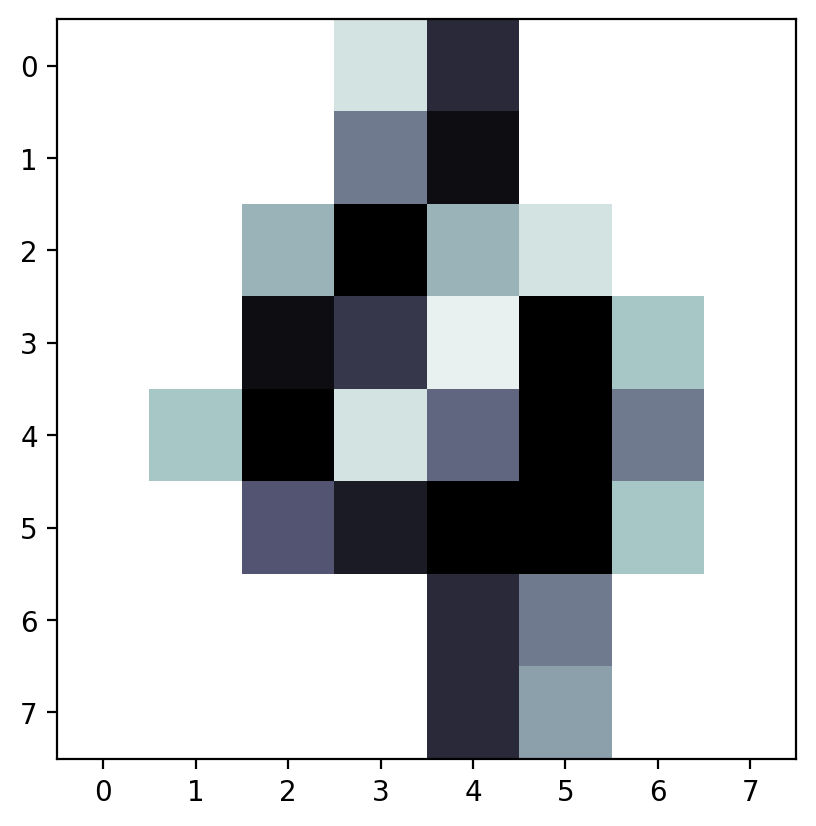

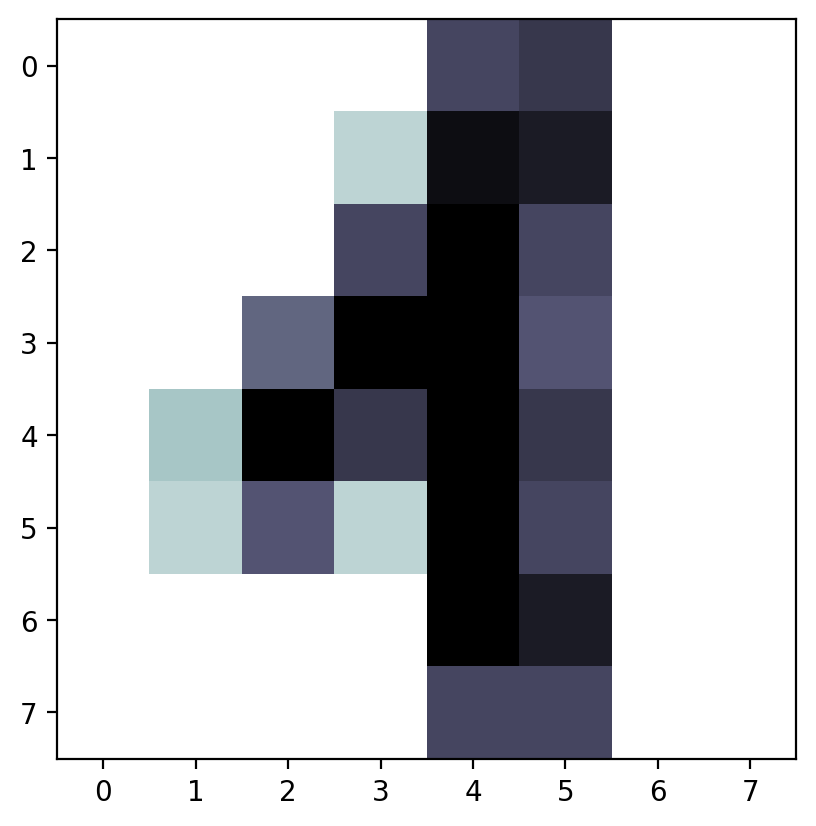

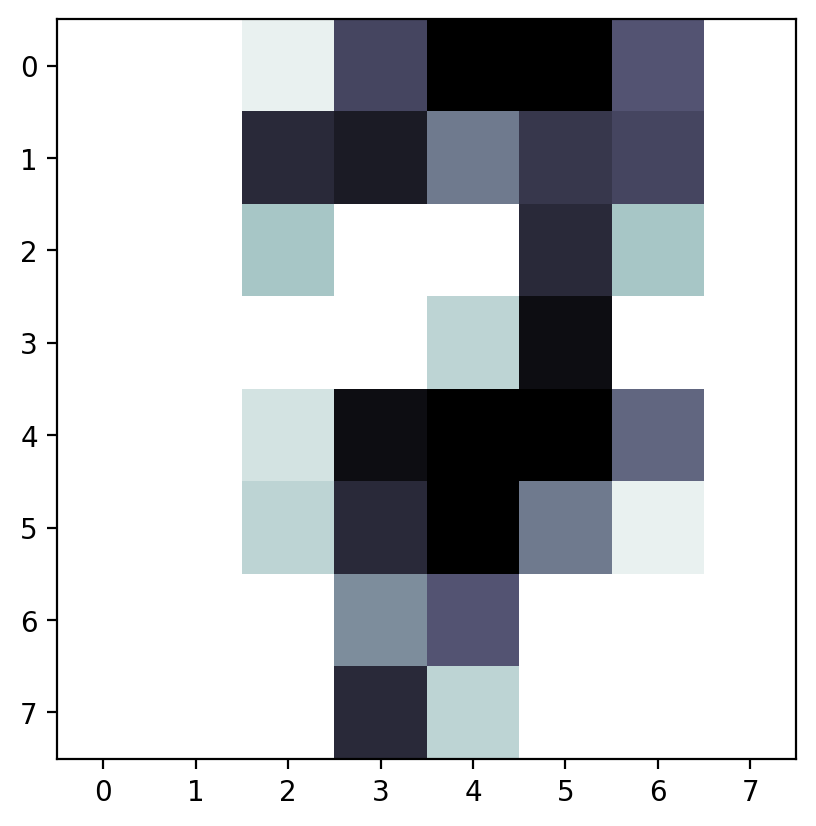

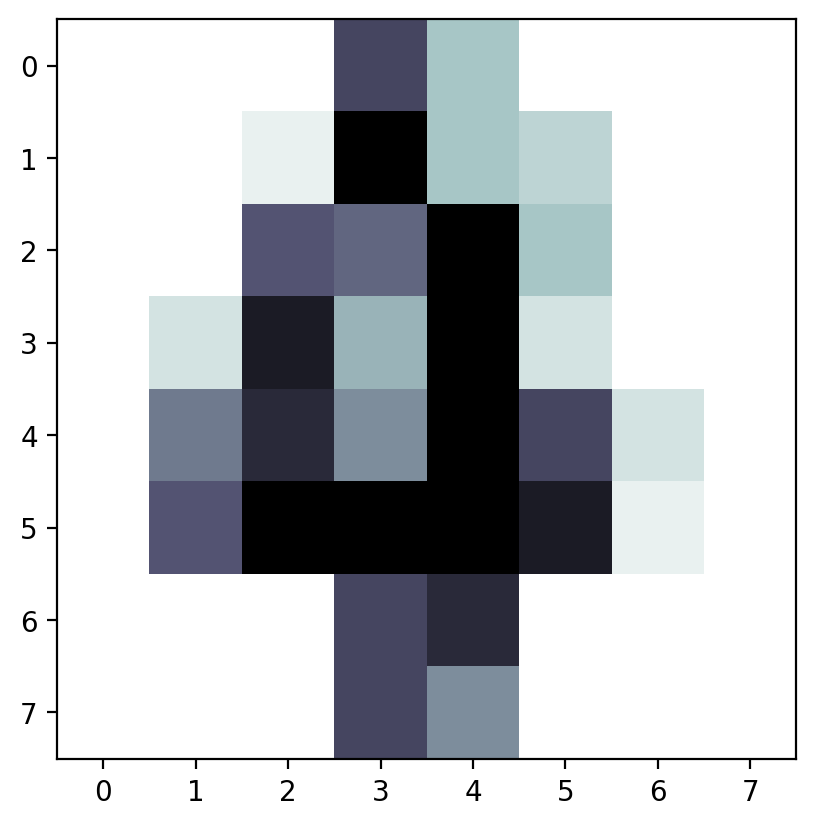

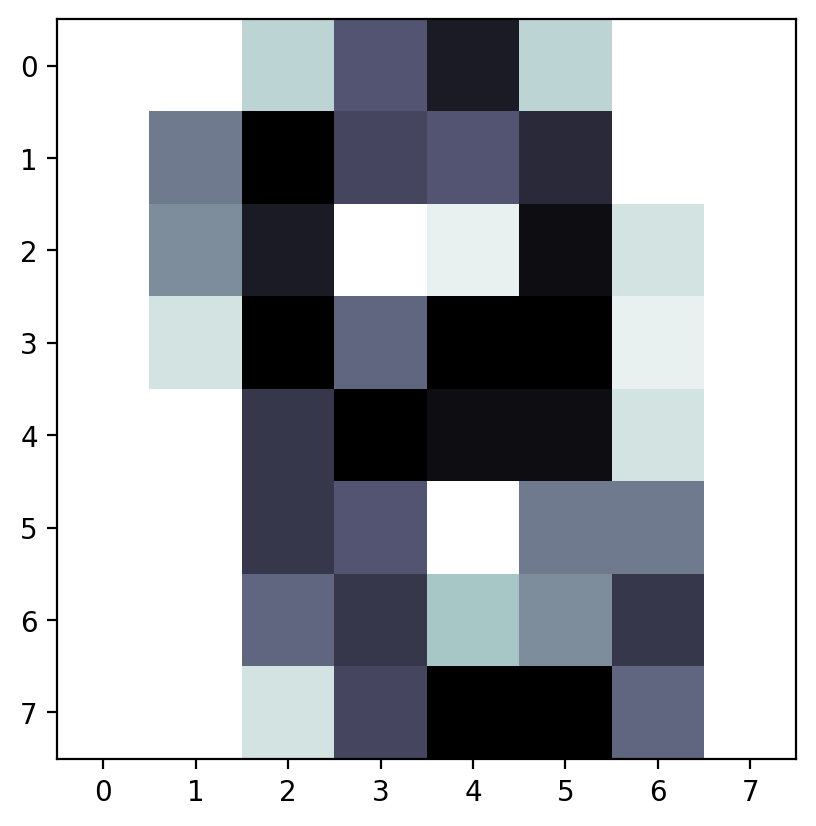

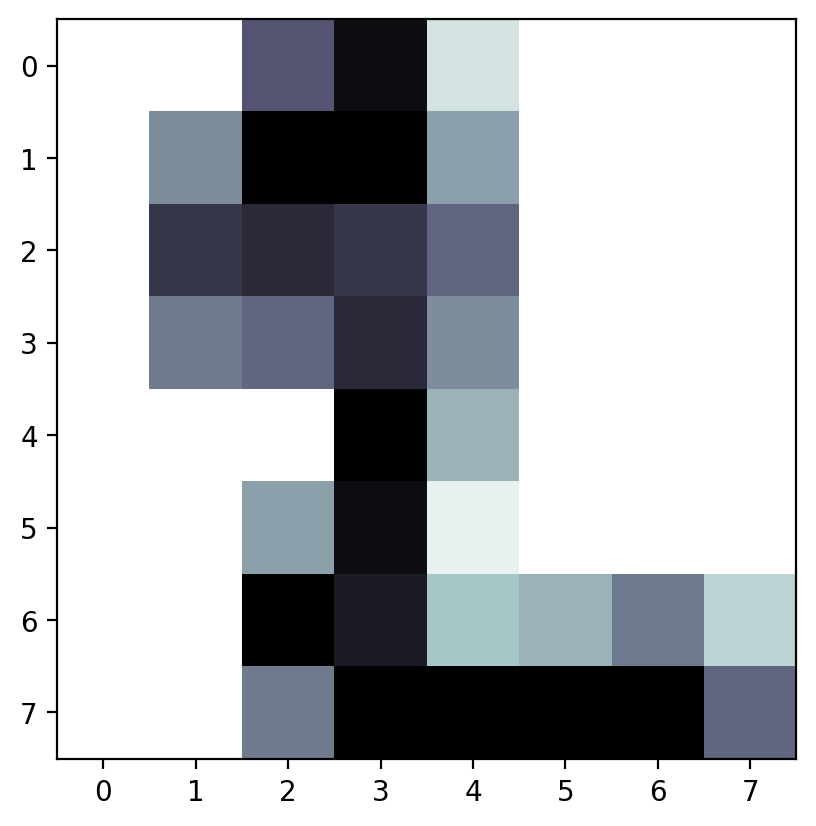

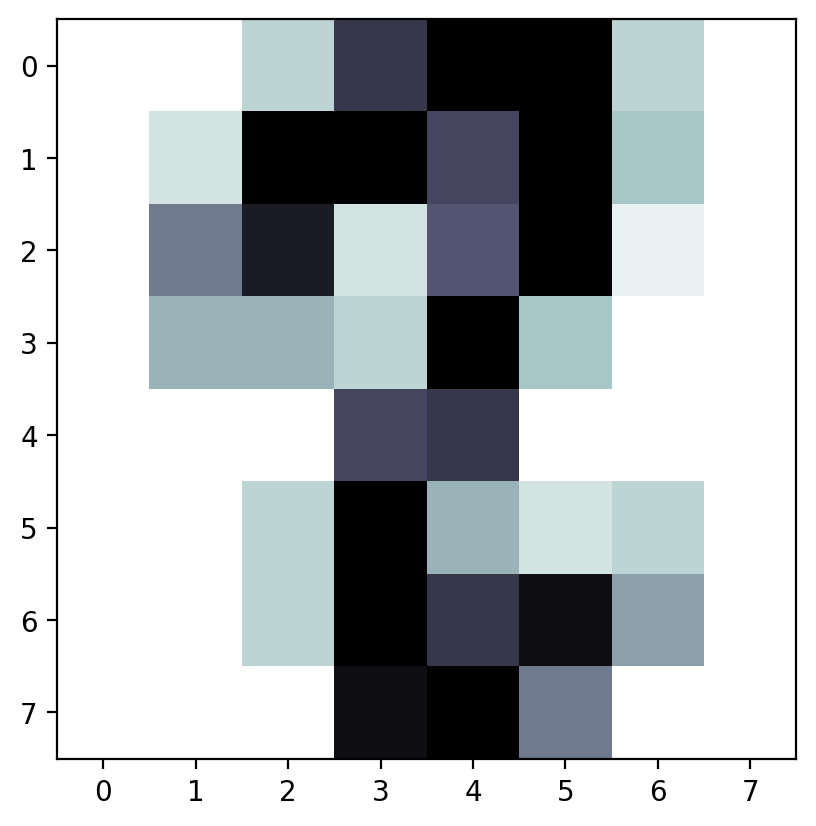

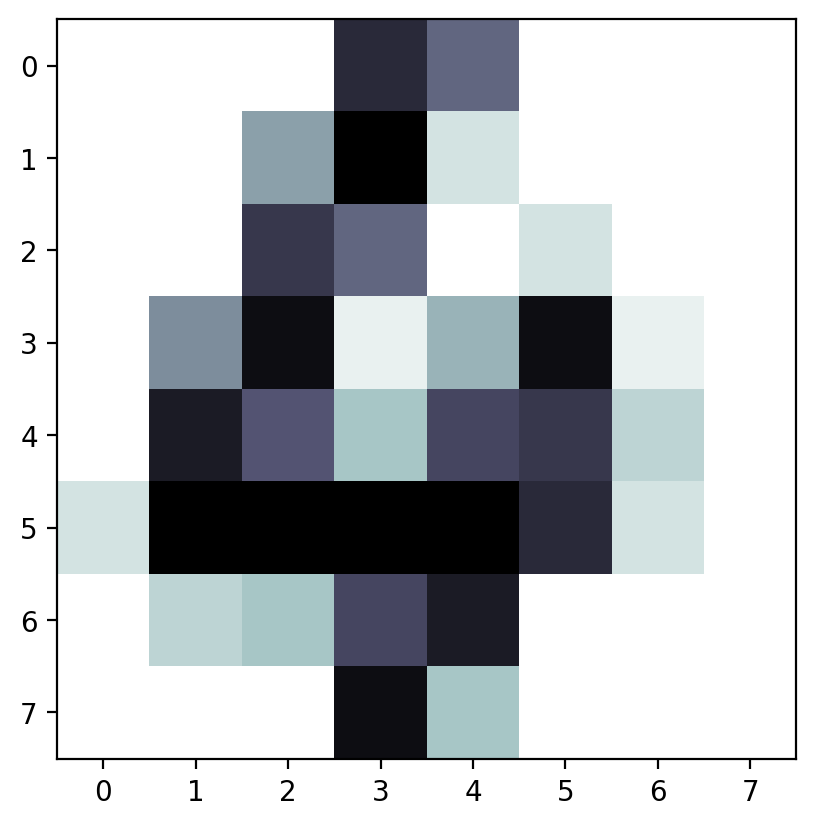

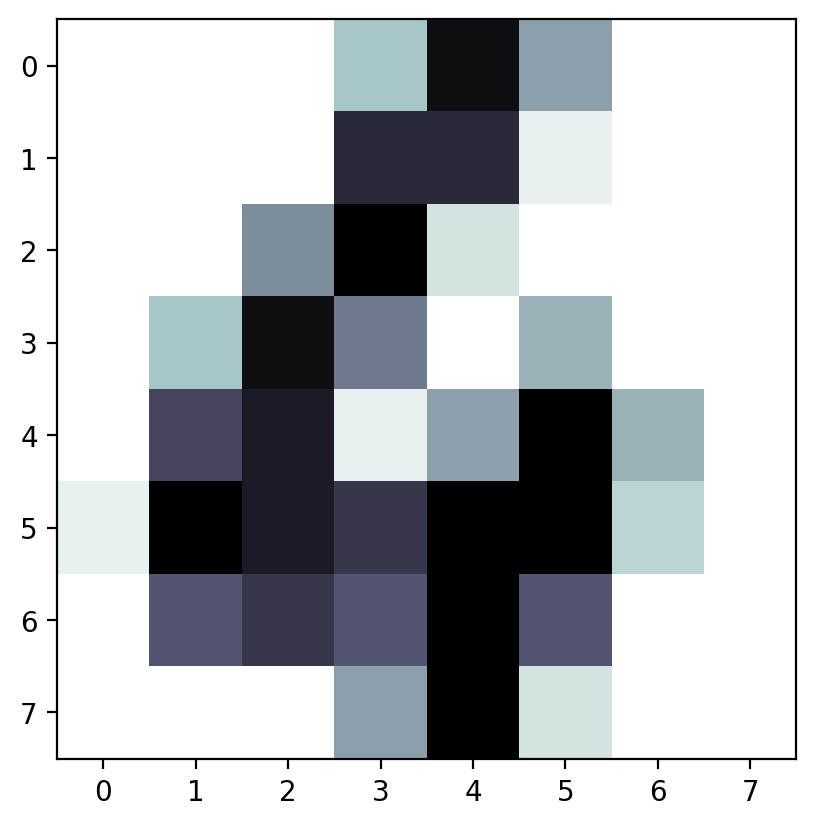

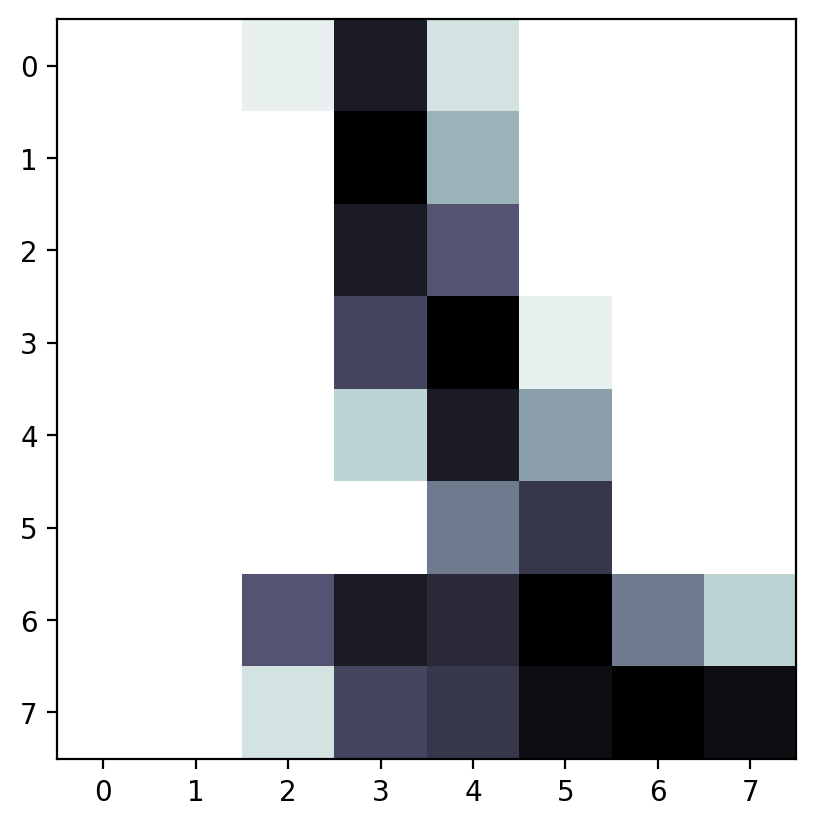

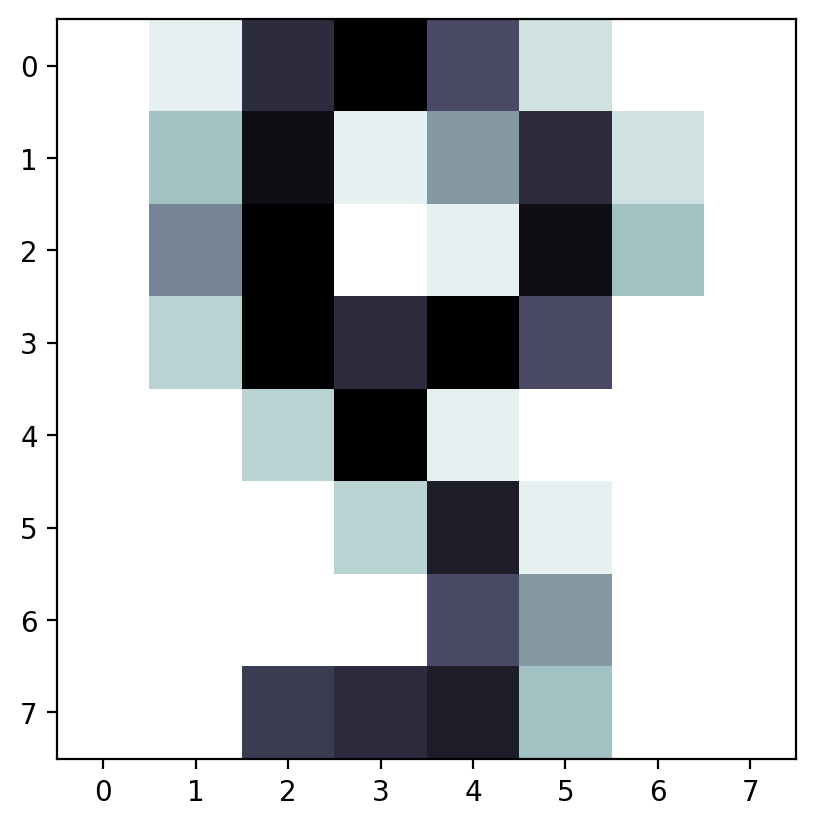

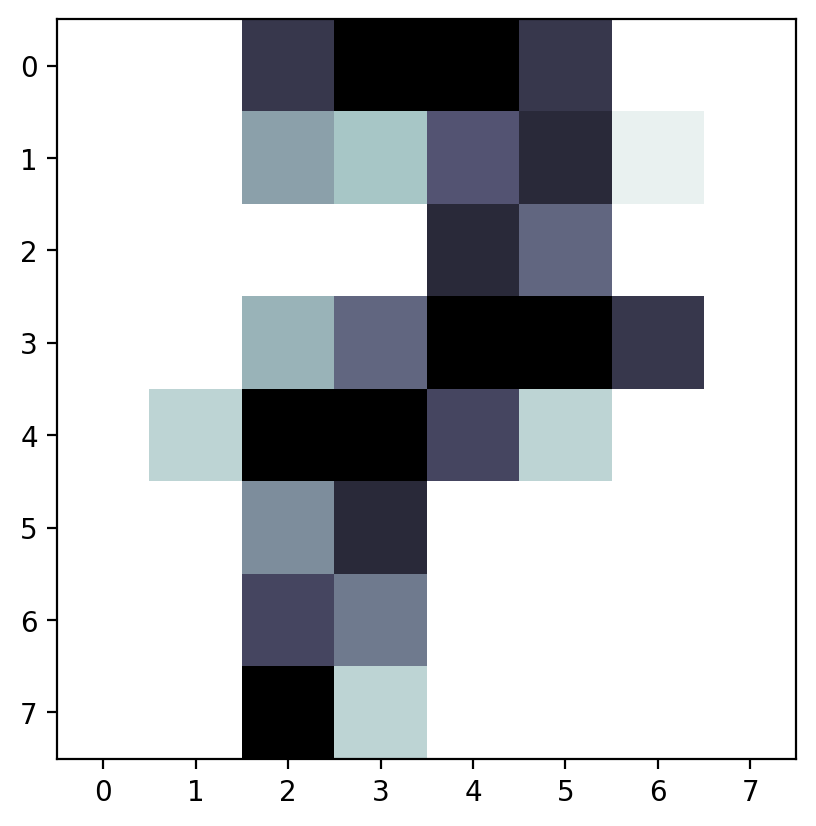

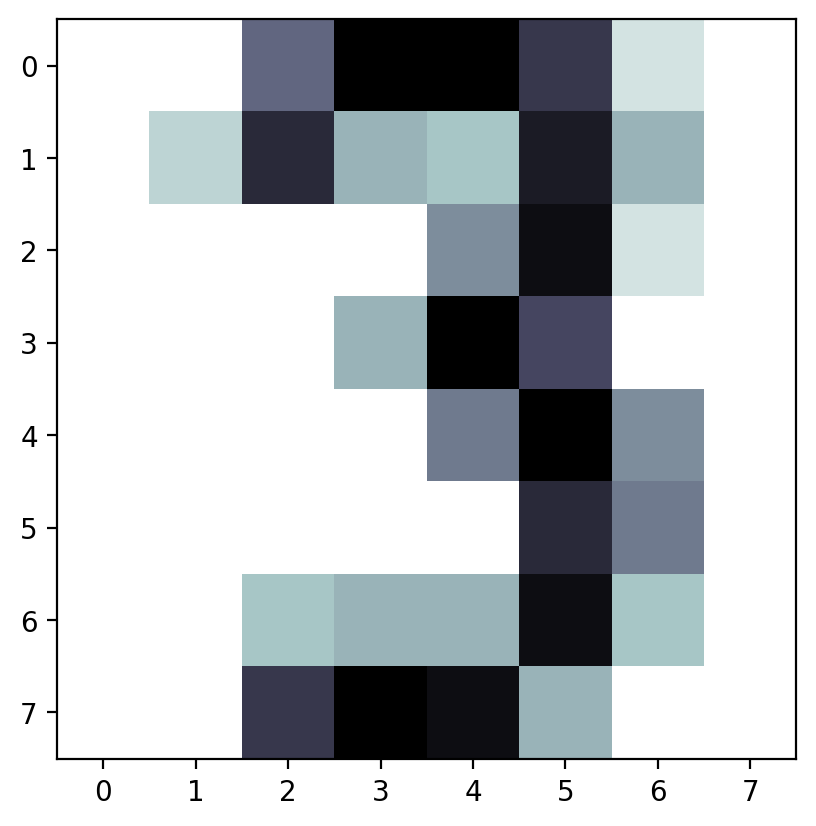

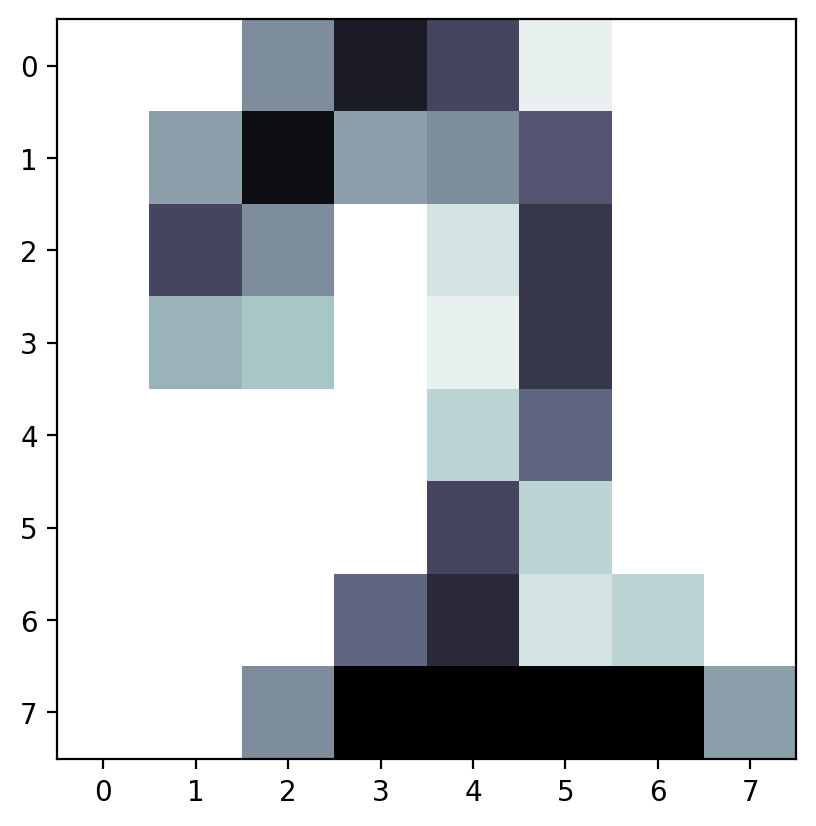

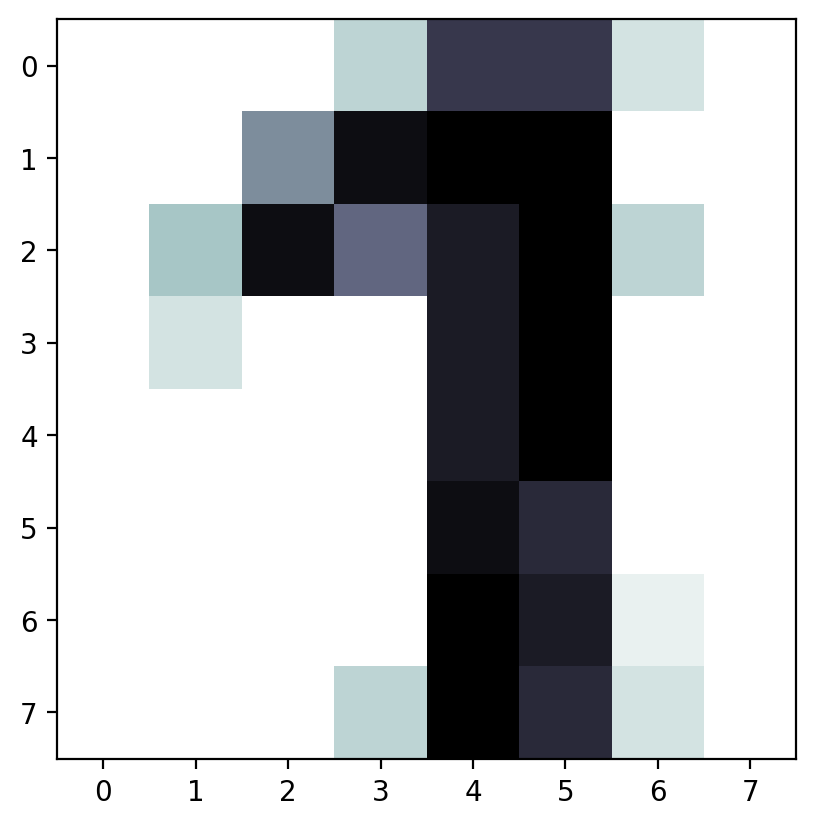

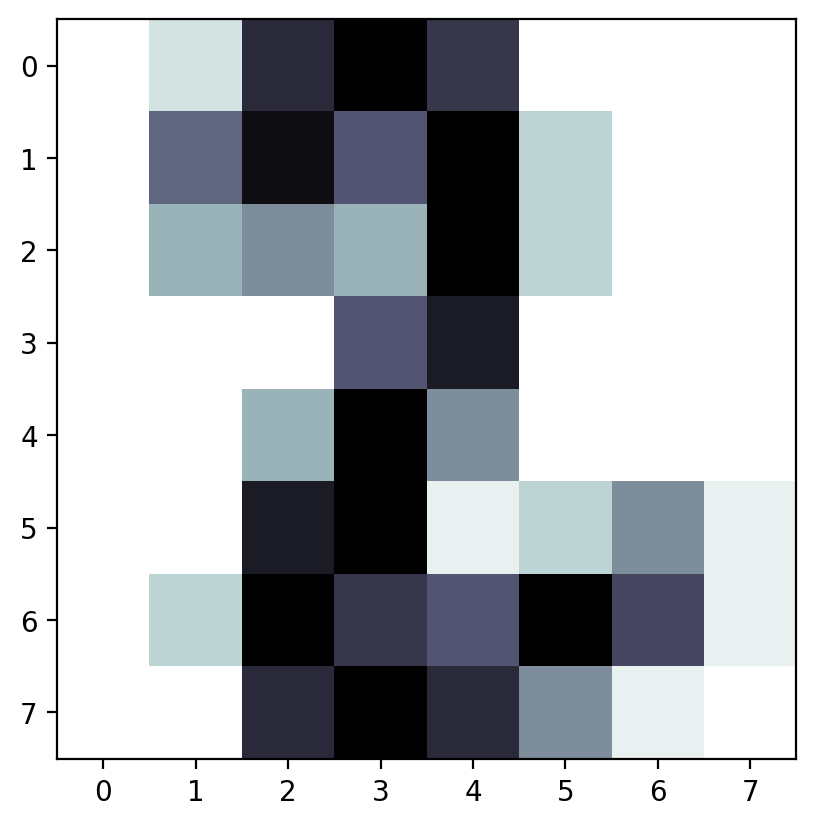

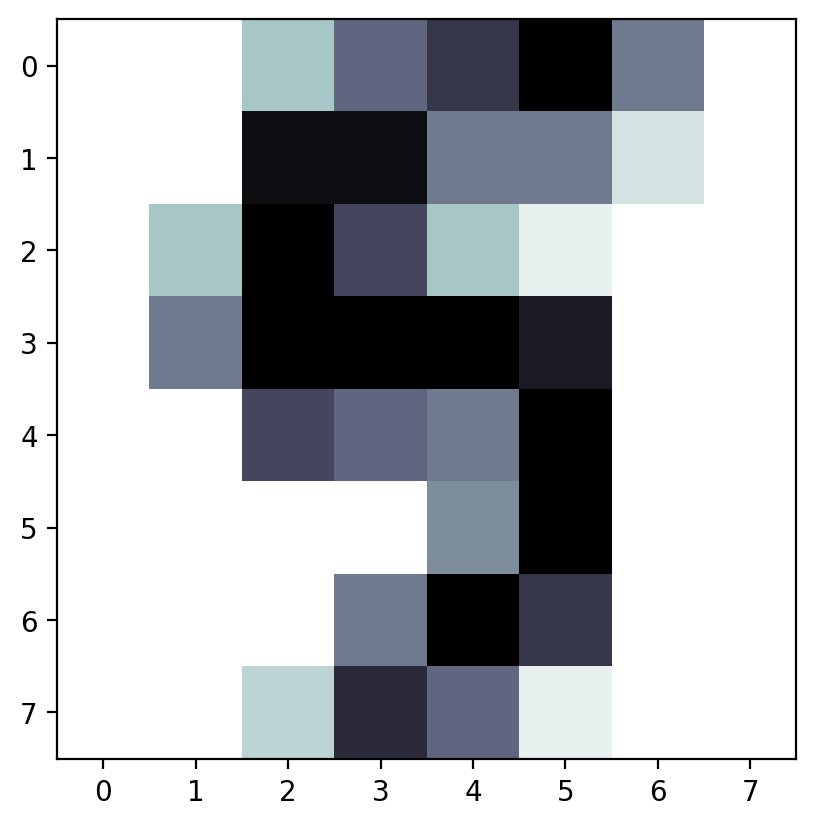

In [30]:
##Load the digits sample
from sklearn.datasets import load_digits

digits = load_digits()
for d in digits.data[::100]:
    grid_data = np.reshape(d, (8,8)) #reshape to 8x8
    plt.imshow(grid_data, interpolation = "nearest", cmap = "bone_r")
    plt.show()
X = digits.data
y = digits.target

Here, we have an $8 \times 8$ pixel grid, giving us 64 total features. Performing PCA on this will reduce the 64 dimensional data to 2 dimensions.

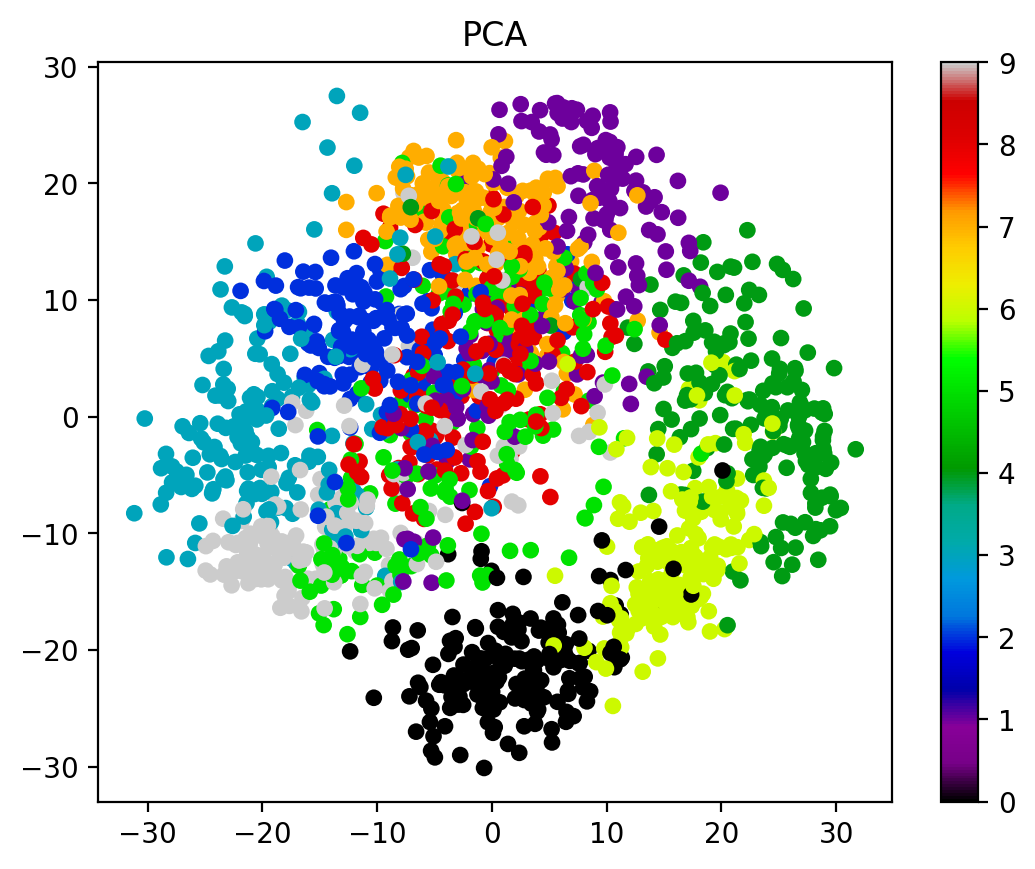

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)
X_reduced = pca.fit_transform(X)
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y, cmap = "nipy_spectral", edgecolors= "None")
plt.title("PCA")
plt.colorbar()

Each dot represents a single $8 \times 8$ image of a handwritten digit. The colours correspond to target digits, mapped by the colourbar on the right. 

Regions where there are distinct clusters show digits with very unique pixel structures that are distinguished easily, whereas the overlapping clusters show that the digits share similarity with other pixel patterns and can't be distinguished easily. For better separation we require non linear methods.

The following shows the same implementation for ICA

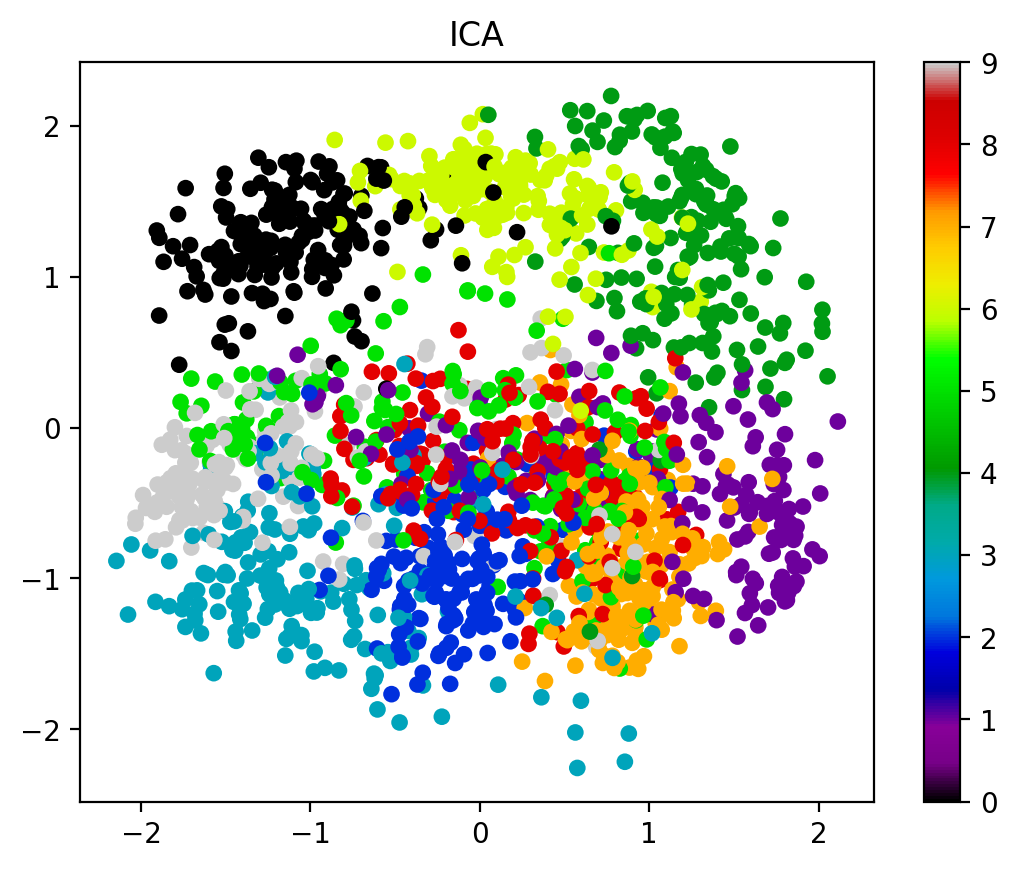

In [32]:
# ICA
from sklearn.decomposition import FastICA
pca = FastICA(n_components = 2)
X_reduced = pca.fit_transform(X)
plt.scatter(X_reduced[:,0], X_reduced[:,1], 
            c=y, cmap="nipy_spectral", edgecolor="None")
plt.title("ICA")
plt.colorbar()

We can also look at using a RandomForestRegressor. This is because we assume that not all pixels in the image are equally useful, so we can see which pixels are most relevant to determine the written number:

[52 36 20 21 28 29 27 35 42 62 26 12 33 34 18 30 51 43 63 13 61 60 10 19
 38 53 54 50 46 58 37  2 22 45  5 44 11 59 25  4  6  3 41 14  9 17 49  1
 57  7 16 15 55 24  8 31 23 47 32 48 56 39 40  0]


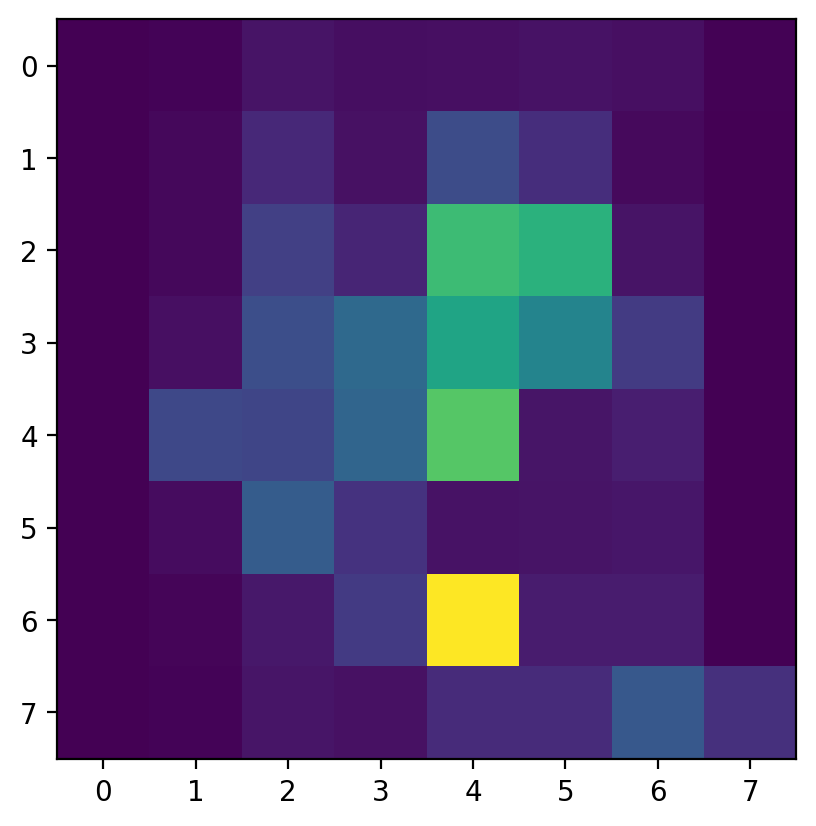

In [33]:
from sklearn.ensemble import RandomForestRegressor

RFreg = RandomForestRegressor() # Complete or leave blank as you see fit
RFreg.fit(X,y) # Do Fitting
importances = RFreg.feature_importances_# Determine pixel "importances"
pixelorder = np.argsort(importances)[::-1] # Rank importances (highest to lowest)
print(pixelorder) 

plt.figure()
plt.imshow(np.reshape(importances,(8,8)),
           interpolation="nearest")
plt.show()

### Manifold Learning

We know that the techniques we have looked at such as PCA, NMF, etc are very useful techniques to reduce the size of data for visualisation, compression, or to help classification and regression. However, real world data has very nonlinear features.

Manifold learning uses a set of techniques to accomplish nonlinear dimensionality reduction

There is a classic case that follows with an S-curve data set. This is a 3D space but the points are from a 2D manifold which is embedded in the space:
> For simplicity lets think of a manifold as a low-dimensional shape embedded inside a higher-dimensional space.


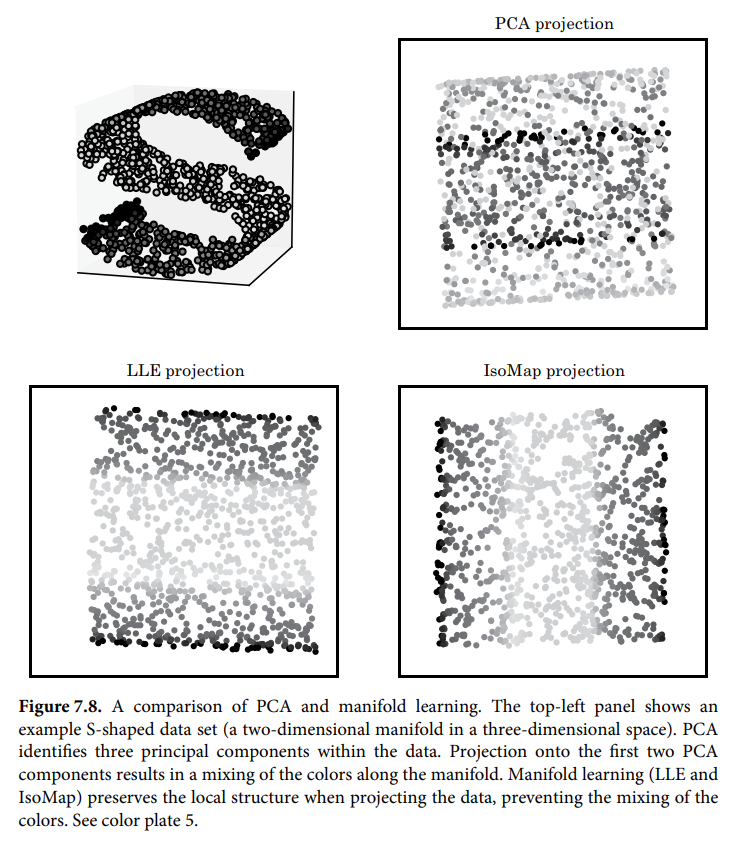


Why do this? Well it is exceptionally useful for working with galaxy and quasar spectra as we did last time. You can get 2 non linear components to recover information that is about as good as dozens of components from linear projections.


## Locally Linear Embedding (LLE)

**LLE** is a non-linear dimensionality reduction method that embeds high-dimensional data into a lower-dimensional space while preserving the geometry of **local neighbourhoods**.

The main assumption is that even if the whole dataset sits on a curved manifold, a small enough neighbourhood around any single point looks approximately flat (linear).



### 1. Characterise the Local Geometry

1. For every point $X_i$, find its $k$ nearest neighbours using Euclidean distance.
   - If $k$ is too small, neighbourhoods can become noisy or disconnected.
   - If $k$ is too large, the neighbourhood is no longer locally linear.

2. Reconstruct each point $X_i$ as a weighted combination of its neighbours:
   $$X_i \approx \sum_j W_{ij} X_j$$

3. Constrain the weights:
   - $W_{ij} = 0$ if point $j$ is not a neighbour of point $i$.
   - $W_{ii} = 0$ so a point cannot trivially reconstruct itself.
   - The weights for each point must sum to one: $\sum_j W_{ij} = 1$.

4. Find the optimal weights by minimising the reconstruction error:
   $$\mathcal{E}(W) = \sum_i \left\| X_i - \sum_j W_{ij} X_j \right\|^2$$

Each row of $W$ is essentially a local recipe describing how a point sits relative to its neighbours. For example, if:
$$X_i \approx 0.2X_a + 0.5X_b + 0.3X_c$$
then $(0.2, 0.5, 0.3)$ describes the relative position of $X_i$. Because local neighbourhoods overlap across the dataset, the matrix $W$ captures the global structure as well.



### 2. Embed the Data in a Lower Dimensional Space

1. Fix the weight matrix $W$ and discard the original coordinates $X$.

2. Find new low-dimensional coordinates $Y_i$ that preserve the same local relationships:
   $$Y_i \approx \sum_j W_{ij} Y_j$$
   So if $X_i \approx 0.2X_a + 0.5X_b + 0.3X_c$, then in the lower-dimensional space we want:
   $$Y_i \approx 0.2Y_a + 0.5Y_b + 0.3Y_c$$

3. Minimise the new embedding error:
   $$\Psi(Y) = \sum_i \left\| Y_i - \sum_j W_{ij} Y_j \right\|^2$$

4. The solution is found by computing the eigenvalues and eigenvectors of:
   $$M = (I - W)^T (I - W)$$
   The eigenvectors corresponding to the smallest non-zero eigenvalues give the final low-dimensional coordinates $Y$.



> Hence, LLE learns how each point relates to its local neighbours, then unfolds all points into fewer dimensions while keeping those local relationships intact.




In [34]:
from sklearn.manifold import LocallyLinearEmbedding

X = np.random.normal(size=(1000,2)) # 1000 points in 2D
R = np.random.random((2,10)) # projection matrix
X = np.dot(X,R) # now a 2D linear manifold in 10D space

k = 5 # Number of neighbors to use in fit
n = 2 # Number of dimensions to fit

lle = LocallyLinearEmbedding(n_neighbors=k, 
                             n_components=n)
lle.fit(X)
proj = lle.transform(X) # 100x2 projection of the data

In [35]:
# Execute this cell to load the digits sample
from sklearn.datasets import load_digits

digits = load_digits()
grid_data = np.reshape(digits.data[0], (8,8)) #reshape to 8x8
#plt.imshow(grid_data, interpolation = "nearest", cmap = "bone_r")
#print(grid_data)
X = digits.data
y = digits.target

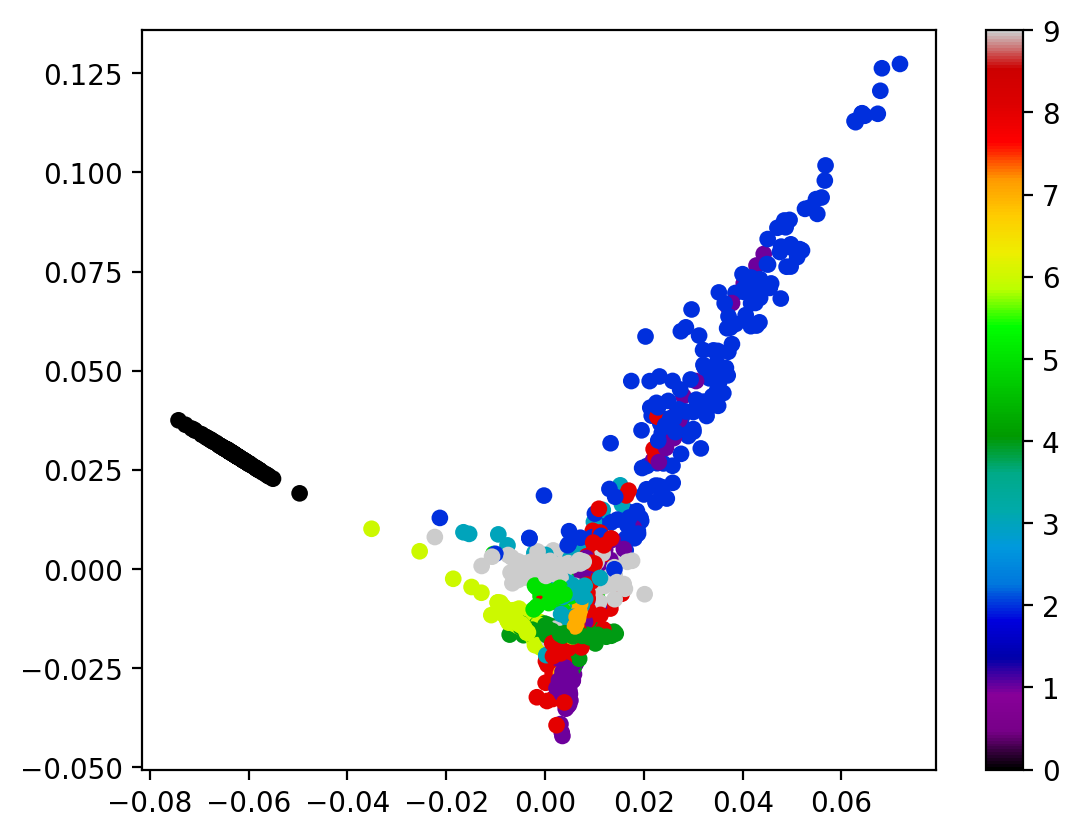

In [36]:
# LLE
from sklearn.manifold import LocallyLinearEmbedding
k = 17 # Number of neighbors to use in fit
n = 2 # Number of dimensions to fit
lle = LocallyLinearEmbedding(n_neighbors=k,
                             n_components=n)
lle.fit(X)
X_reduced = lle.transform(X)

plt.scatter(X_reduced[:,0], X_reduced[:,1], 
            c=y, cmap="nipy_spectral", edgecolor="None")
plt.colorbar();

What does this graph mean?

The axis dont actually mean too much, they are just what the LLE found.

The biggest feature is the blue continuous sequence (2), this shows that the LLE found a chain of locally connected objects

The black branch (the number 0) is shaped as such because the objects within it are very similar to eachother and dissimilar to the main population

The cluster of objects shows that the digits look similar in pixel space

### Isometric Mapping (IsoMap)

This tries to find a lower dimensional embedding of the data matrix that maintains the geodesic distances between all points. This is the distance along the manifold.

So it approximates geodesic distances by constructing a nearest-neighbour graph and finding the shortest path through this graph between each pair of points.


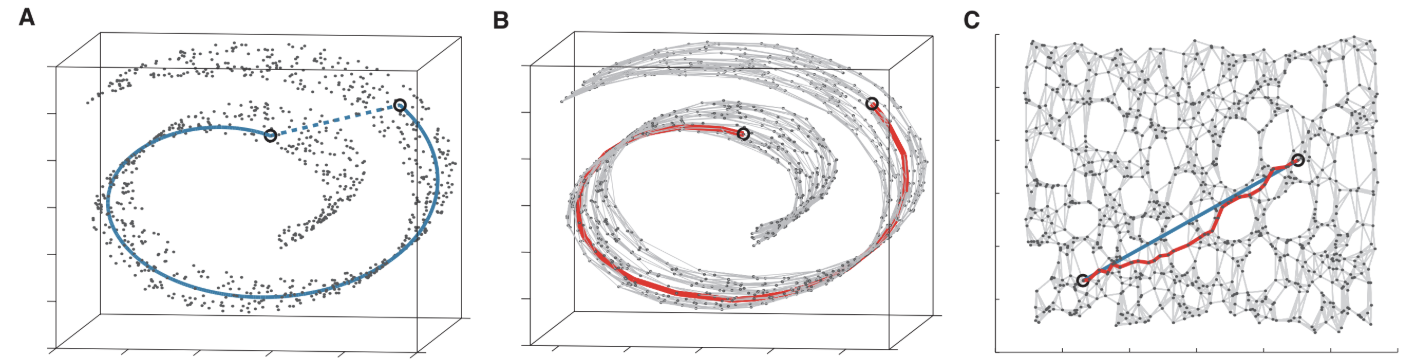

1. We can see in the left panel that the euclidean distance between the two points (the dashed line) is not a good representation of how far apart they are on the embedded manifold (solid blue line)
2. In the middle panel, a neighbourhood graph is constructed that connects each point to its neighbours. This allows the geodesic distance between the points to be computed by finding the shortest distance through the graph. This can be done through Dijkstras algorithm or similar
3. The right panel shows a lower dimensional embedding of the manifold recovered by IsoMap that preserves the relative geodesic distances between points.

The final step for finding the optimal low dimensional embedding. MDS algorithm techniques are used to minimize the reconstruction error

$$\mathcal{E}_{XY} = |\tau(\tilde{D}_X) - \tau(D_Y)|^2$$

between the original data set $X$ and the low-dimensional embedding, $Y$, where $\tau$ is some operator on distance matrices.

- $\tilde{D}_X$ is the estimated geodesic distances from the shortest paths through the NN graph
- $D_Y$ is the ordinary pairwise distances in the new low dimensionl embedding
- $\tau$ is the transformation used by MDS



We can implement it as follows



In [37]:
# Execute this cell
from sklearn.manifold import Isomap

XX = np.random.normal(size=(1000,2)) # 1000 points in 2D
R = np.random.random((2,10)) # projection matrix
XX = np.dot(XX,R) # X is a 2D manifold in 10D space

k = 5 # number of neighbors
n = 2 # number of dimensions

iso = Isomap(n_neighbors=k, n_components=n)
iso.fit(XX)
proj = iso.transform(XX) # 1000x2 projection of the data

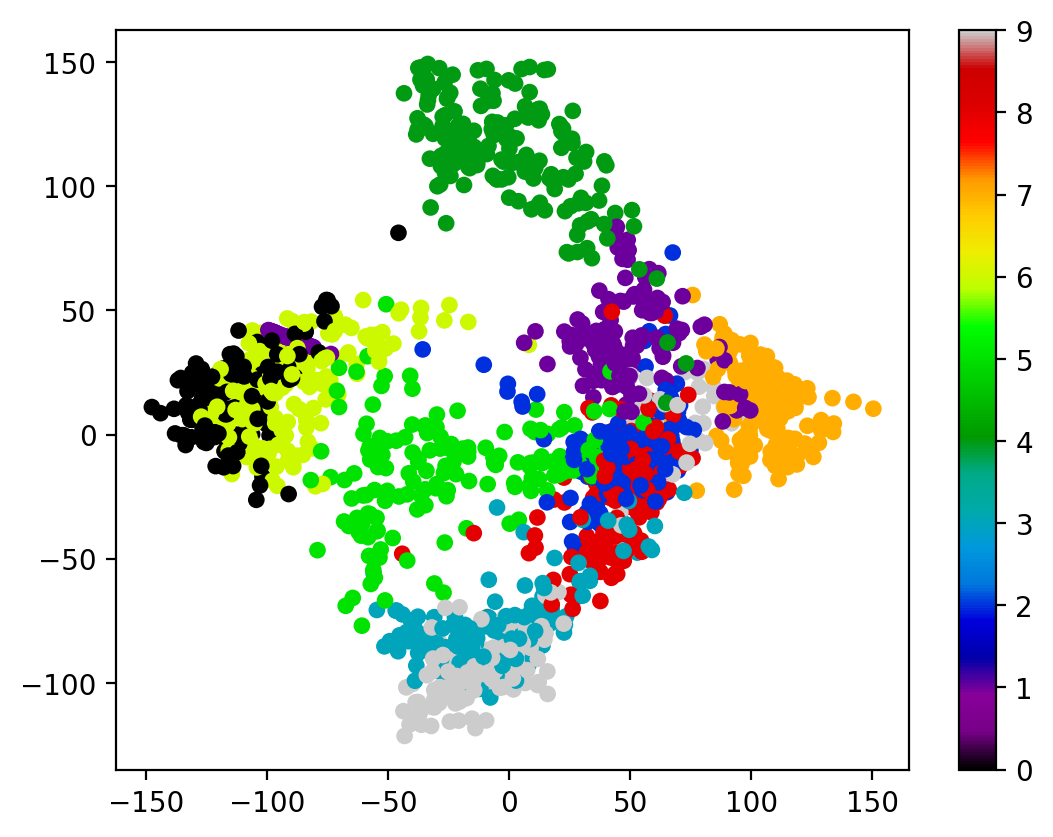

In [38]:
# IsoMap
k = 7 # Number of neighbors to use in fit
n = 2 # Number of dimensions to fit

iso = Isomap(n_neighbors=k,
             n_components=n)
iso.fit(X)

X_reduced = iso.transform(X)

plt.scatter(X_reduced[:,0], X_reduced[:,1], 
            c=y, cmap="nipy_spectral", edgecolor="None")
plt.colorbar();

This is applied to the same digits dataset!

We can see distinct coloured clusters, meaning that IsoMap has discovered that many images of the same digit have similar high dimensional structure.

For example the orange cluster is quite compact, so the 7's are quite similar to each other and distinct to others. As we would expect, 1 creeps in there too.

The overlapping colours show that they look similar enough in pixel space that the neighbourhoods overlap.

### t -distributed Stochastic Neighbour Embedding (t-SNE)

This is yet another manifold learning algorithm that isn't mentioned in Izevic.

PCA finds linear directions that maximise variance, whereas t-SNE focuses on preserving local neighbour similarities.

Description for t-SNE (complexish)

Step 1: Measure the similarity between points in the original high-dimensional space
- This is done by centering a multivariate Gaussian on each point and measuring the pdf value of all the neighbours
- THe bandwidth of the Gaussian can be chosen to tweak something called the perplexity, which essentially relates to the nearest neighbours being considered
- The result is a matrix of probabilities of each point under a Gaussian centered under every other point $p_{ij}$
- The similarity matrix is a measure of local structure

Step 2: Find the lower dimensional mapping that preserves the similarities $p_{ij}$
- A heavy tailed **t** distribution is used with 1 degree of freedom to model the probabilities between pairs of points in low dimension embedding, $q_{ij}$
- This allows objects that are dissimilar to be modeled as far apart on the map
- Then a quantity known as the Kullback-Liebler divergence is used to minimize differences between $p_{ij}$ and $q_{ij}$


#### Now for a simpler explanation:

t-SNE tries to create a lower dimensional map of high-dimensional data while keeping points that were similar in the original data close together.

1. Measure how similar the original points are
- For each point, look at the distances to all of the other points
- Nearby points are given a high similarity, while far away points are given a very small similarity
- These similarities are converted into probabilities $p_{ij}$
- Therefore, a large $p_{ij}$ means that points $i$ and $j$ should probably be close together on the final map
- Perplexity controls roughly how large a neighbourhood each point pays attention to

2. Place the points in the lower dimensional space
- Initially place the points in the new 2D or 3D space
- Calculate their similarities again, giving probabilities $q_{ij}$
- A Student-$t$ distribution is used here, which allows dissimilar points to move much further apart

3. Compare the two maps and move the points
- Compare the original similarities $p_{ij}$ with the new similarities $q_{ij}$
- If two points had a high similarity originally but are far apart in the new map, move them closer together
- If two points were dissimilar originally but are too close in the new map, move them further apart
- Repeat this process until the neighbourhood structure of the low-dimensional map is as similar as possible to the original data
- The difference between $p_{ij}$ and $q_{ij}$ is measured using the Kullback-Leibler divergence

$$D_{KL}(P||Q)=\sum_{i,j}p_{ij}\log\left(\frac{p_{ij}}{q_{ij}}\right)$$

> TLDR: t-SNE works out which points should be neighbours in the original high-dimensional data, then moves points around in a lower-dimensional map until those same neighbours are close together.


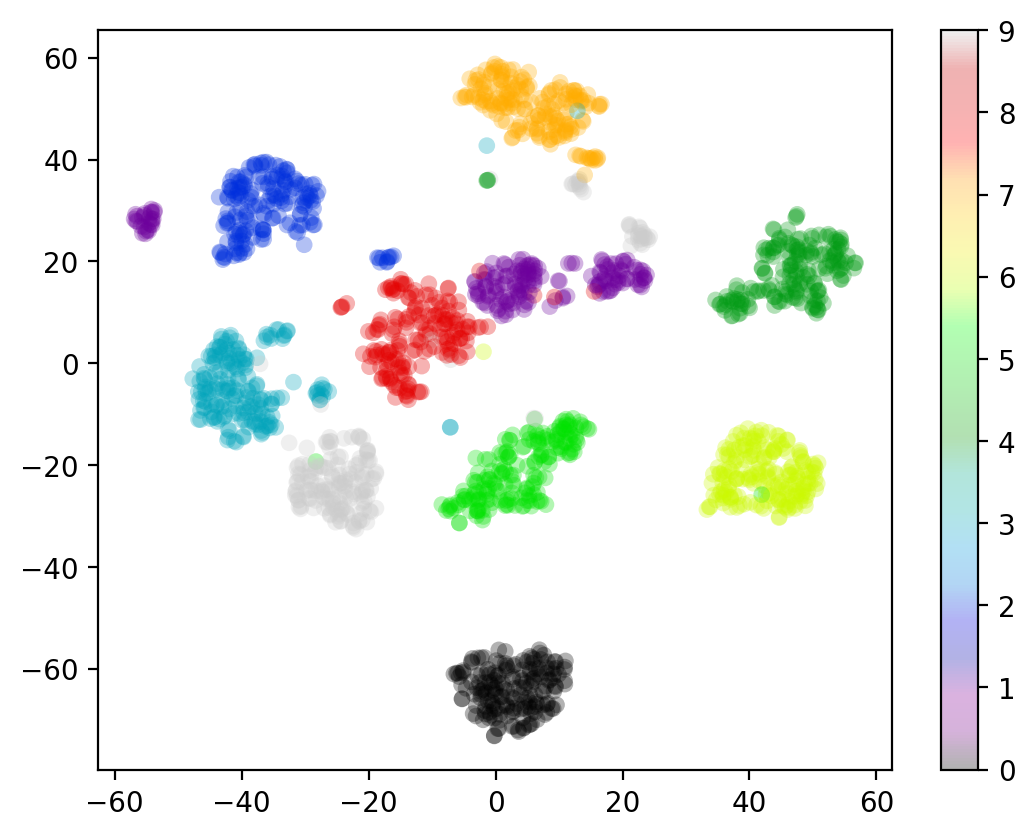

In [39]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,learning_rate=200)
X_reduced = tsne.fit_transform(X)

plt.scatter(X_reduced[:,0],X_reduced[:,1], 
            c=y, cmap="nipy_spectral", alpha=0.3, 
            edgecolor="None")
plt.colorbar()

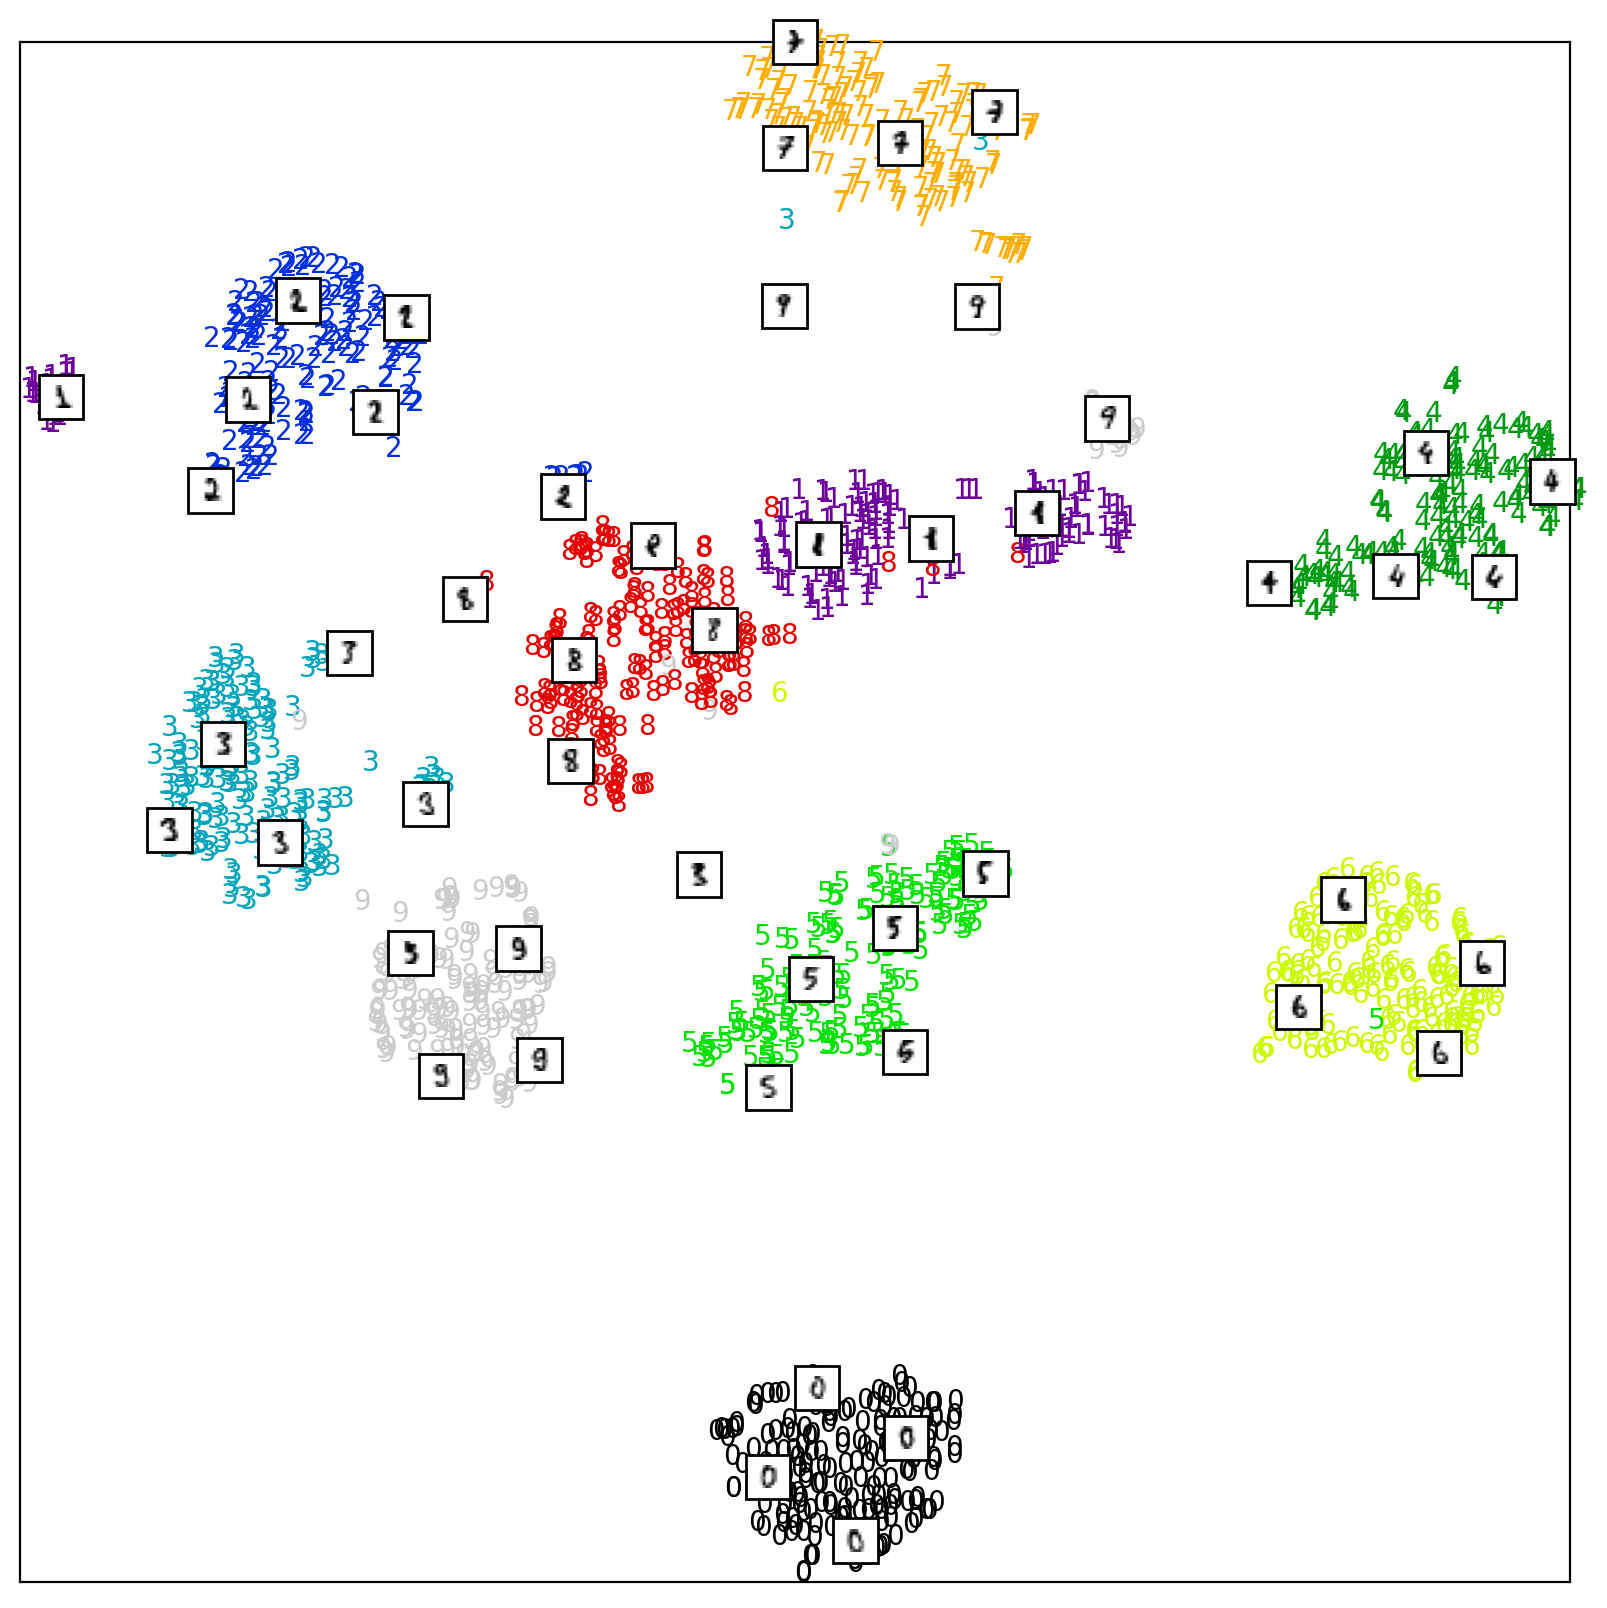

In [40]:
# Execute this cell
from matplotlib import offsetbox

#----------------------------------------------------------------------
# Scale and visualize the embedding vectors
def plot_embedding(X):
    x_min, x_max = np.min(X, 0), np.max(X, 0)
    X = (X - x_min) / (x_max - x_min)

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111)
    for i in range(X.shape[0]):
        plt.text(X[i, 0], X[i, 1], str(digits.target[i]), 
                 color=plt.cm.nipy_spectral(y[i]/9.))

    shown_images = np.array([[1., 1.]])  # just something big
    for i in range(digits.data.shape[0]):
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.r_[shown_images, [X[i]]]
        imagebox = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(digits.images[i],
                                  cmap=plt.cm.gray_r), 
            X[i])
        ax.add_artist(imagebox)
    plt.xticks([]), plt.yticks([])
    
plot_embedding(X_reduced)
plt.show()

This is insanely powerful, and great for visualisation.

### Draw backs of nonlinear techniques (too good to be true?)

 - **Noisy and gappy data.** For our S problem, imagine a point at x=0,y=0 but unconstrained in z. The algorithm cannot possibly know where to put it on the S. Manifold learning tecniques are intrisically bad for missing data.
- **Tuning parameters.** Sophisticated things needs to be tuned (I didn't even mention the learning rate parmeter in t-SNE!)
- **Dimensionality** In PCA, the eigenvalue give you a sense of the intrinsic dimensionality, i.e. how many dimensions you should keep. This is not the case with non-linear approaches.
- **Outliers** can be a big problem for these tools. There's a nice example on this in Fig 7.9 in the textbook. If you look at the code, they first have to filter out outliers with a different algorithm before applying LLE successfully.
- **Reconstruction.** Non-linear mapping does not provide a set of basis function like PCA, making data reconstruction less clean (need to use e.g. nearest neighbors).

### Quick final thoughts
- **PCA:** preserve variance
- **LLE:** preserve local reconstruction relationships
- **Isomap:** preserve distances along the manifold
- **t-SNE:** preserve local neighbour similarities

Resources!

[Locally Linear Embedding](https://www.youtube.com/watch?v=scMntW3s-Wk)